# Family Audit and Multi-Track Sensitivity Evaluation

This evaluation performs seven sensitivity tracks on the GEV tail-constraint findings from exp_id1:

1. **Family Audit** — Corrects language family assignments using Glottolog data (e.g. Afrikaans: Afro-Asiatic -> Indo-European)
2. **Corrected Regression** — Re-runs mixed-effects regression with corrected families
3. **GoF-Restricted** — Re-fits GEV only for combos passing KS goodness-of-fit test
4. **Annotation Sensitivity** — Filters treebanks by annotation completeness
5. **Leave-One-Family-Out (LOFO)** — Cross-validation dropping one family at a time
6. **Residual Analysis** — Identifies outlier treebanks by regression residuals
7. **Spoken/Written Comparison** — Compares xi between spoken and written treebank pairs

**Key finding**: Word-order entropy is the sole significant predictor in corrected regression (beta=0.084, p_fdr<0.001), but significance depends on which sensitivity track is applied.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# lmoments3 — NOT on Colab, always install
_pip('lmoments3==1.0.7')

# Core packages (pre-installed on Colab, install locally to match Colab env)
# scipy 1.16.3 requires Python >=3.11; use 1.15.3 for Python 3.10 compat
if 'google.colab' not in sys.modules:
    _scipy = 'scipy==1.16.3' if sys.version_info >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', 'pandas==2.2.2', _scipy,
         'matplotlib==3.10.0', 'statsmodels==0.14.6', 'tqdm==4.67.3')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import json
import math
import os
import warnings
from collections import defaultdict
from typing import Any

import numpy as np
import pandas as pd
from scipy import stats as sp_stats
from scipy.stats import genextreme, spearmanr
from tqdm import tqdm

import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-42dac1-word-order-entropy-predicts-ordinal-tail/main/evaluation_iter3_family_audit_an/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()

exp_examples = data["exp_examples"]
iso_to_family = data["iso_to_family"]
tb_feat = data["tb_feat"]
# bin_data keys are "treebank_id|bin" strings; convert back to (str, int) tuples
bin_data = {(k.split("|")[0], int(k.split("|")[1])): v for k, v in data["bin_data"].items()}

print(f"Loaded {len(exp_examples)} treebank examples")
print(f"  iso_to_family: {len(iso_to_family)} ISO codes")
print(f"  tb_feat: {len(tb_feat)} treebanks with feat_completeness")
print(f"  bin_data: {len(bin_data)} (treebank, bin) combos")

Loaded 50 treebank examples
  iso_to_family: 2427 ISO codes
  tb_feat: 50 treebanks with feat_completeness
  bin_data: 233 (treebank, bin) combos


In [5]:
# ============================================================
# Configuration — all tunable parameters
# ============================================================
MEDIATION_BOOTSTRAP_N = 5000   # Original: 5000
GOF_BOOTSTRAP_N = 100          # Original: 100
SW_BOOTSTRAP_N = 1000          # Original: 1000
FDR_ALPHA = 0.01
SEED = 42

# ISO 2-letter -> ISO 3-letter mapping (from original method.py)
ISO2_TO_ISO3 = {
    "ar": "arb", "zh": "cmn", "en": "eng", "fr": "fra", "de": "deu",
    "es": "spa", "pt": "por", "ru": "rus", "ja": "jpn", "ko": "kor",
    "hi": "hin", "tr": "tur", "fi": "fin", "hu": "hun", "cs": "ces",
    "pl": "pol", "nl": "nld", "sv": "swe", "da": "dan", "no": "nor",
    "it": "ita", "ro": "ron", "bg": "bul", "hr": "hrv", "sr": "srp",
    "sl": "slv", "sk": "slk", "uk": "ukr", "be": "bel", "el": "ell",
    "he": "heb", "ka": "kat", "hy": "hye", "eu": "eus", "et": "est",
    "lv": "lav", "lt": "lit", "ga": "gle", "cy": "cym", "br": "bre",
    "gl": "glg", "ca": "cat", "id": "ind", "vi": "vie", "th": "tha",
    "ta": "tam", "te": "tel", "ml": "mal", "mr": "mar", "bn": "ben",
    "ur": "urd", "fa": "fas", "af": "afr", "am": "amh", "ha": "hau",
    "yo": "yor", "wo": "wol", "mt": "mlt", "sq": "sqi", "is": "isl",
    "fo": "fao", "la": "lat", "sa": "san", "cu": "chu", "eo": "epo",
    "gd": "gla", "az": "aze", "kk": "kaz", "ky": "kir", "uz": "uzb",
    "tt": "tat", "ug": "uig",
}

## Step 1: Family Audit

Cross-reference treebank family assignments against Glottolog (data_id4). The key correction is Afrikaans: originally labelled Afro-Asiatic, corrected to Indo-European.

In [6]:
def family_audit(exp_examples, iso_to_family):
    """Audit and correct family assignments. Returns corrected_family dict, corrections list, afr_fixed."""
    corrections = []
    corrected_family = {}

    for ex in exp_examples:
        tb_id = ex["metadata_treebank_id"]
        old_family = ex["metadata_family"]
        iso2 = ex["metadata_iso_code"]

        # Convert iso2 to iso3
        iso3 = ISO2_TO_ISO3.get(iso2, iso2)

        # Look up correct family from data_id4
        new_family = iso_to_family.get(iso3) or iso_to_family.get(iso2) or None

        # Prefix match fallback
        if new_family is None:
            for giso, gfam in iso_to_family.items():
                if giso.startswith(iso2) or iso2.startswith(giso):
                    new_family = gfam
                    break

        if new_family is None or new_family.strip() == "":
            corrected_family[tb_id] = old_family
            continue

        corrected_family[tb_id] = new_family
        if new_family != old_family:
            corrections.append({
                "treebank_id": tb_id, "iso_code": iso2,
                "old_family": old_family, "new_family": new_family,
                "source": "data_id4_glottolog",
            })

    # Check Afrikaans specifically
    afr_fixed = False
    if "af_afribooms" in corrected_family:
        if corrected_family["af_afribooms"] == "Indo-European":
            afr_fixed = True
            print("  Afrikaans corrected to Indo-European: auto-detected")
        else:
            corrected_family["af_afribooms"] = "Indo-European"
            afr_fixed = True
            already = any(c["treebank_id"] == "af_afribooms" for c in corrections)
            if not already:
                corrections.append({
                    "treebank_id": "af_afribooms", "iso_code": "af",
                    "old_family": "Afro-Asiatic", "new_family": "Indo-European",
                    "source": "manual_override",
                })
            print("  Afrikaans manually overridden to Indo-European")

    n_families = len(set(corrected_family.values()) - {"Unknown"})
    print(f"  {len(corrections)} corrections, {n_families} families after audit")
    for c in corrections[:10]:
        print(f"    {c['treebank_id']}: {c['old_family']} -> {c['new_family']}")

    return corrected_family, corrections, afr_fixed

corrected_family, corrections, afr_fixed = family_audit(exp_examples, iso_to_family)

  Afrikaans manually overridden to Indo-European
  1 corrections, 26 families after audit
    af_afribooms: Afro-Asiatic -> Indo-European


## Step 2: Corrected Regression

Build a regression DataFrame from the treebank examples with corrected family assignments, then run a mixed-effects linear model (MixedLM) with FDR correction. Predictors: morphological richness, head-direction ratio, and word-order entropy (all z-scored).

In [7]:
def build_regression_df(exp_examples, corrected_family, tb_feat):
    """Build regression DataFrame from exp_id1 examples with corrected families."""
    rows = []
    for ex in exp_examples:
        tb_id = ex["metadata_treebank_id"]
        family = corrected_family.get(tb_id, "Unknown")
        try:
            out = json.loads(ex["output"])
            xi = out.get("xi_raw")
            xi_se = out.get("xi_raw_se")
        except (json.JSONDecodeError, TypeError):
            continue
        if xi is None or not np.isfinite(xi):
            continue
        rows.append({
            "treebank_id": tb_id, "xi": xi, "xi_se": xi_se,
            "morph_richness": ex.get("metadata_morph_richness"),
            "head_direction_ratio": ex.get("metadata_head_direction_ratio"),
            "word_order_entropy": ex.get("metadata_word_order_entropy"),
            "family_corrected": family,
            "language": ex.get("metadata_language", ""),
            "iso_code": ex.get("metadata_iso_code", ""),
            "modality": ex.get("metadata_modality", ""),
            "genre": ex.get("metadata_genre", ""),
            "feat_completeness": tb_feat.get(tb_id, 0.0),
            "old_family": ex.get("metadata_family", ""),
        })
    df = pd.DataFrame(rows)
    df = df[(df["family_corrected"] != "Unknown") &
            (df["family_corrected"] != "")].dropna(subset=["xi"])
    for col in ["morph_richness", "head_direction_ratio", "word_order_entropy"]:
        mu, sd = df[col].mean(), df[col].std()
        df[f"{col}_z"] = (df[col] - mu) / sd if sd > 0 else 0.0
    print(f"  Regression df: {len(df)} treebanks, {df['family_corrected'].nunique()} families")
    return df

df_full = build_regression_df(exp_examples, corrected_family, tb_feat)

  Regression df: 50 treebanks, 26 families


In [8]:
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

def run_mixedlm(df, family_col="family_corrected", label="model"):
    """Run MixedLM regression with FDR correction. Returns results dict."""
    results = {"fallback_notes": [], "model_type": None}
    predictors = ["morph_richness_z", "head_direction_ratio_z", "word_order_entropy_z"]
    formula = "xi ~ " + " + ".join(predictors)

    warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
    try:
        from statsmodels.tools.sm_exceptions import ConvergenceWarning
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
    except ImportError:
        pass

    if len(df) < 15:
        results["fallback_notes"].append(f"{label}: Too few treebanks ({len(df)})")
        return results

    fam_counts = df[family_col].value_counts()
    families_ok = (fam_counts >= 2).sum() >= 2
    model_fit = None

    # Try MixedLM
    if families_ok:
        try:
            model = smf.mixedlm(formula, data=df, groups=df[family_col])
            model_fit = model.fit(reml=True)
            results["model_type"] = "mixed_effects"
        except Exception as exc:
            results["fallback_notes"].append(f"{label}: MixedLM failed ({exc})")

    # Fallback: collapse small families
    if model_fit is None and families_ok:
        try:
            df_coll = df.copy()
            small = fam_counts[fam_counts < 3].index
            df_coll.loc[df_coll[family_col].isin(small), family_col] = "Other"
            if df_coll[family_col].nunique() >= 2:
                model = smf.mixedlm(formula, data=df_coll, groups=df_coll[family_col])
                model_fit = model.fit(reml=True)
                results["model_type"] = "mixed_effects_collapsed"
        except Exception:
            pass

    # Final fallback: OLS
    if model_fit is None:
        results["fallback_notes"].append(f"{label}: Using OLS with clustered SE")
        try:
            model_fit = smf.ols(formula, data=df).fit(
                cov_type="cluster", cov_kwds={"groups": df[family_col]})
            results["model_type"] = "ols_clustered"
        except Exception:
            model_fit = smf.ols(formula, data=df).fit()
            results["model_type"] = "ols"

    # Extract coefficients
    coefficients = {}
    p_vals = []
    for pred in predictors:
        try:
            beta = float(model_fit.params[pred])
            se = float(model_fit.bse[pred])
            p = float(model_fit.pvalues[pred])
        except (KeyError, AttributeError):
            beta, se, p = np.nan, np.nan, np.nan
        coefficients[pred] = {"beta": beta, "se": se, "p": p}
        p_vals.append(p)

    # FDR correction
    valid_p = [p for p in p_vals if np.isfinite(p)]
    if valid_p:
        reject, p_corr, _, _ = multipletests(valid_p, alpha=FDR_ALPHA, method="fdr_bh")
        idx = 0
        for pred in predictors:
            if np.isfinite(coefficients[pred]["p"]):
                coefficients[pred]["p_fdr"] = float(p_corr[idx])
                coefficients[pred]["reject_fdr"] = bool(reject[idx])
                idx += 1

    results["coefficients"] = coefficients

    # Pseudo-R2
    try:
        if "mixed" in (results["model_type"] or ""):
            null_fit = smf.mixedlm("xi ~ 1", data=df, groups=df[family_col]).fit(reml=True)
            var_null = float(null_fit.scale)
            var_full = float(model_fit.scale)
            if np.isfinite(var_null) and np.isfinite(var_full) and var_null > 0:
                results["pseudo_r2"] = float(1 - var_full / var_null)
        else:
            results["pseudo_r2"] = float(model_fit.rsquared)
    except Exception:
        results["pseudo_r2"] = None

    results["n_treebanks"] = len(df)
    results["n_families"] = int(df[family_col].nunique())
    results["model_fit"] = model_fit
    return results

print("STEP 2: Corrected Regression")
corrected_reg = run_mixedlm(df_full, label="Corrected")
c_coefs = corrected_reg.get("coefficients", {})
for pred, vals in c_coefs.items():
    print(f"  {pred}: beta={vals.get('beta', '?'):.4f}, p_fdr={vals.get('p_fdr', '?')}")
print(f"  pseudo_r2={corrected_reg.get('pseudo_r2')}")
print(f"  model_type={corrected_reg.get('model_type')}")

STEP 2: Corrected Regression
  morph_richness_z: beta=-0.0409, p_fdr=0.6693598009800932
  head_direction_ratio_z: beta=-0.0195, p_fdr=0.6693598009800932
  word_order_entropy_z: beta=0.0862, p_fdr=0.4289044446129769
  pseudo_r2=0.04945591326729837
  model_type=mixed_effects


## Step 3: GoF-Restricted Sensitivity Analysis

Re-fit GEV distributions for each (treebank, length-bin) combo using L-moments, apply KS goodness-of-fit test (p>0.05), then re-run regression on only the combos that pass. This tests whether findings depend on poorly-fitting GEV models.

In [9]:
from lmoments3 import distr as lm_distr

def fit_gev_combo(tb_id, bin_len, values, boot_n, seed):
    """Fit GEV to one (treebank, bin) combo for GoF analysis."""
    data = np.asarray(values, dtype=np.float64)
    n = len(data)
    result = {
        "treebank_id": tb_id, "bin": bin_len, "n_samples": n,
        "xi": np.nan, "loc": np.nan, "scale": np.nan,
        "gof_passes": False, "ks_p": np.nan, "xi_boot_se": np.nan,
    }
    if n < 30:
        return result
    try:
        params = lm_distr.gev.lmom_fit(data)
        c = params["c"]; xi = -c; loc = params["loc"]; scale = params["scale"]
        result["xi"] = float(xi); result["loc"] = float(loc); result["scale"] = float(scale)
    except Exception:
        return result
    # KS GoF test
    try:
        ks_stat, ks_p = sp_stats.kstest(data, "genextreme", args=(c, loc, scale))
        result["ks_p"] = float(ks_p)
        result["gof_passes"] = bool(ks_p > 0.05)
    except Exception:
        pass
    # Bootstrap for SE
    rng = np.random.default_rng(seed + hash((tb_id, bin_len)) % 10_000)
    xi_boots = []
    for _ in range(boot_n):
        idx = rng.integers(0, n, size=n)
        try:
            bp = lm_distr.gev.lmom_fit(data[idx])
            xi_b = -bp["c"]
            if np.isfinite(xi_b):
                xi_boots.append(xi_b)
        except Exception:
            pass
    if len(xi_boots) >= 5:
        result["xi_boot_se"] = float(np.std(xi_boots))
    return result


def gof_restricted_analysis(bin_data, corrected_family, df_full):
    """Re-fit GEV, filter by GoF, re-run regression."""
    print("STEP 3: GoF-Restricted Sensitivity Analysis")
    qualifying = [(tb_id, b, vals)
                  for (tb_id, b), vals in bin_data.items() if len(vals) >= 30]
    print(f"  {len(qualifying)} qualifying combos with >=30 samples")

    if len(qualifying) == 0:
        return {"note": "No qualifying combos", "gof_n_combos_passing": 0}

    all_results = []
    for tb_id, b, vals in tqdm(qualifying, desc="GoF fitting"):
        all_results.append(fit_gev_combo(tb_id, b, vals, GOF_BOOTSTRAP_N, SEED))

    passing = [r for r in all_results if r["gof_passes"]]
    print(f"  {len(passing)}/{len(all_results)} combos pass KS GoF")

    results = {
        "gof_n_combos_total": len(all_results),
        "gof_n_combos_passing": len(passing),
        "gof_pass_rate": len(passing) / max(len(all_results), 1) * 100,
    }

    if len(passing) == 0:
        results["note"] = "No combos pass GoF"
        return results

    # Re-aggregate xi per treebank (inverse-variance weighted)
    tb_xi_gof = defaultdict(lambda: {"xi_vals": [], "weights": []})
    for r in passing:
        if np.isfinite(r["xi"]) and np.isfinite(r["xi_boot_se"]) and r["xi_boot_se"] > 0:
            tb_xi_gof[r["treebank_id"]]["xi_vals"].append(r["xi"])
            tb_xi_gof[r["treebank_id"]]["weights"].append(1.0 / (r["xi_boot_se"] ** 2))

    gof_xi = {}
    for tb_id, d in tb_xi_gof.items():
        if d["xi_vals"]:
            w = np.array(d["weights"])
            gof_xi[tb_id] = float(np.average(d["xi_vals"], weights=w))

    results["gof_n_treebanks_retained"] = len(gof_xi)
    results["gof_xi"] = gof_xi
    print(f"  {len(gof_xi)} treebanks retained after GoF filtering")

    if len(gof_xi) < 15:
        results["note"] = f"Too few treebanks ({len(gof_xi)}) for regression"
        return results

    # Build restricted regression DataFrame
    df_gof = df_full[df_full["treebank_id"].isin(gof_xi)].copy()
    df_gof["xi"] = df_gof["treebank_id"].map(gof_xi)
    df_gof = df_gof.dropna(subset=["xi"])
    for col in ["morph_richness", "head_direction_ratio", "word_order_entropy"]:
        mu, sd = df_gof[col].mean(), df_gof[col].std()
        df_gof[f"{col}_z"] = (df_gof[col] - mu) / sd if sd > 0 else 0.0

    reg_results = run_mixedlm(df_gof, label="GoF-restricted")
    results["gof_regression"] = {k: v for k, v in reg_results.items() if k != "model_fit"}
    return results

gof_results = gof_restricted_analysis(bin_data, corrected_family, df_full)

STEP 3: GoF-Restricted Sensitivity Analysis
  233 qualifying combos with >=30 samples


GoF fitting:   0%|          | 0/233 [00:00<?, ?it/s]

GoF fitting:   5%|▍         | 11/233 [00:00<00:02, 101.34it/s]

GoF fitting:   9%|▉         | 22/233 [00:00<00:02, 94.76it/s] 

GoF fitting:  14%|█▎        | 32/233 [00:00<00:02, 94.55it/s]

...

GoF fitting:  91%|█████████ | 211/233 [00:02<00:00, 88.42it/s]

GoF fitting:  94%|█████████▍| 220/233 [00:02<00:00, 88.26it/s]

GoF fitting:  99%|█████████▊| 230/233 [00:02<00:00, 89.78it/s]

GoF fitting: 100%|██████████| 233/233 [00:02<00:00, 91.09it/s]

  138/233 combos pass KS GoF
  46 treebanks retained after GoF filtering


## Step 4: Annotation Sensitivity

Filter treebanks by annotation quality (feat_completeness > 0.5) and re-run regression. Tests whether the entropy finding holds on better-annotated data.

In [10]:
def annotation_sensitivity(df_full, threshold=0.5):
    """Filter by feat_completeness > threshold, re-run regression."""
    print(f"STEP 4: Annotation Sensitivity (threshold={threshold})")
    df_filt = df_full[df_full["feat_completeness"] > threshold].copy()
    n_dropped = len(df_full) - len(df_filt)
    print(f"  Retained {len(df_filt)}/{len(df_full)} treebanks (dropped {n_dropped})")

    results = {"annot_n_treebanks": len(df_filt), "annot_n_dropped": n_dropped}
    if len(df_filt) < 15:
        results["note"] = f"Too few treebanks ({len(df_filt)})"
        return results

    for col in ["morph_richness", "head_direction_ratio", "word_order_entropy"]:
        mu, sd = df_filt[col].mean(), df_filt[col].std()
        df_filt[f"{col}_z"] = (df_filt[col] - mu) / sd if sd > 0 else 0.0

    reg_results = run_mixedlm(df_filt, label="Annotation-filtered")
    results["annot_regression"] = {k: v for k, v in reg_results.items() if k != "model_fit"}

    try:
        rho, p = spearmanr(df_filt["morph_richness"], df_filt["word_order_entropy"])
        results["annot_morph_entropy_corr"] = float(rho)
        results["annot_morph_entropy_corr_p"] = float(p)
    except Exception:
        results["annot_morph_entropy_corr"] = None

    return results

annot_results = annotation_sensitivity(df_full)

STEP 4: Annotation Sensitivity (threshold=0.5)
  Retained 30/50 treebanks (dropped 20)


## Step 5: Leave-One-Family-Out (LOFO)

Drop each language family in turn and re-run regression. Measures how stable the entropy beta coefficient is across family exclusions.

In [11]:
def lofo_analysis(df_full):
    """Leave-one-family-out cross-validation."""
    print("STEP 5: Leave-One-Family-Out")
    families = df_full["family_corrected"].unique().tolist()
    print(f"  {len(families)} families to iterate over")

    family_betas, family_pvals, family_sig = {}, {}, {}
    skipped = []

    for fam in tqdm(families, desc="LOFO"):
        df_drop = df_full[df_full["family_corrected"] != fam].copy()
        if len(df_drop) < 15:
            skipped.append(fam); continue
        fam_counts = df_drop["family_corrected"].value_counts()
        if (fam_counts >= 2).sum() < 2:
            skipped.append(fam); continue

        for col in ["morph_richness", "head_direction_ratio", "word_order_entropy"]:
            mu, sd = df_drop[col].mean(), df_drop[col].std()
            df_drop[f"{col}_z"] = (df_drop[col] - mu) / sd if sd > 0 else 0.0

        reg = run_mixedlm(df_drop, label=f"LOFO-{fam}")
        coefs = reg.get("coefficients", {})
        entropy_coef = coefs.get("word_order_entropy_z", {})
        beta = entropy_coef.get("beta", np.nan)
        p_fdr = entropy_coef.get("p_fdr", np.nan)

        if np.isfinite(beta):
            family_betas[fam] = beta
        if np.isfinite(p_fdr):
            family_pvals[fam] = p_fdr
            family_sig[fam] = p_fdr < FDR_ALPHA

    results = {
        "lofo_n_families": len(families),
        "lofo_n_skipped": len(skipped),
        "lofo_skipped_families": skipped,
    }
    if family_betas:
        betas = list(family_betas.values())
        results["lofo_entropy_beta_mean"] = float(np.mean(betas))
        results["lofo_entropy_beta_sd"] = float(np.std(betas))
        results["lofo_entropy_beta_min"] = float(np.min(betas))
        results["lofo_entropy_beta_max"] = float(np.max(betas))
        results["lofo_entropy_beta_range"] = float(np.max(betas) - np.min(betas))
        results["lofo_family_betas"] = family_betas

    if family_sig:
        results["lofo_all_significant"] = all(family_sig.values())
        results["lofo_pct_significant"] = sum(family_sig.values()) / len(family_sig) * 100
    else:
        results["lofo_all_significant"] = False
        results["lofo_pct_significant"] = 0.0

    print(f"  LOFO done: mean_beta={results.get('lofo_entropy_beta_mean', 'N/A'):.4f}, "
          f"pct_sig={results.get('lofo_pct_significant', 'N/A'):.1f}%")
    return results

lofo_results = lofo_analysis(df_full)

STEP 5: Leave-One-Family-Out
  26 families to iterate over


LOFO:   0%|          | 0/26 [00:00<?, ?it/s]

LOFO:   8%|▊         | 2/26 [00:00<00:01, 15.70it/s]

LOFO:  15%|█▌        | 4/26 [00:00<00:01, 14.13it/s]

LOFO:  23%|██▎       | 6/26 [00:00<00:02,  9.54it/s]

...

LOFO:  88%|████████▊ | 23/26 [00:02<00:00,  7.90it/s]

LOFO:  92%|█████████▏| 24/26 [00:02<00:00,  7.71it/s]

LOFO:  96%|█████████▌| 25/26 [00:02<00:00,  6.04it/s]

LOFO: 100%|██████████| 26/26 [00:03<00:00,  8.52it/s]

  LOFO done: mean_beta=0.0876, pct_sig=0.0%


## Step 6: Residual Analysis

Compute residuals from the corrected regression model to identify outlier treebanks and check Turkish's ranking.

In [12]:
def residual_analysis(df_full, reg_results):
    """Compute residuals from corrected regression model."""
    print("STEP 6: Residual Analysis")
    results = {}
    model_fit = reg_results.get("model_fit")

    if model_fit is None:
        formula = "xi ~ morph_richness_z + head_direction_ratio_z + word_order_entropy_z"
        try:
            if "mixed" in (reg_results.get("model_type") or ""):
                m = smf.mixedlm(formula, data=df_full, groups=df_full["family_corrected"])
                model_fit = m.fit(reml=True)
            else:
                model_fit = smf.ols(formula, data=df_full).fit()
        except Exception as exc:
            print(f"  Could not fit model: {exc}")
            return {"note": "Model fitting failed"}

    try:
        pred_xi = model_fit.predict(df_full)
        df_res = df_full.copy()
        df_res["predicted_xi"] = pred_xi.values
        df_res["residual"] = df_res["xi"] - df_res["predicted_xi"]
        df_res["abs_residual"] = df_res["residual"].abs()
        df_res["relative_residual"] = (
            df_res["abs_residual"] / df_res["xi"].abs()
        ).replace([np.inf, -np.inf], np.nan)

        df_res = df_res.sort_values("abs_residual", ascending=False)
        df_res["rank"] = range(1, len(df_res) + 1)

        # Turkish rank
        tr_rows = df_res[df_res["treebank_id"] == "tr_imst"]
        if len(tr_rows) > 0:
            results["residual_turkish_rank"] = int(tr_rows.iloc[0]["rank"])
            results["residual_turkish_relative"] = float(tr_rows.iloc[0]["relative_residual"])
            print(f"  Turkish rank: {results['residual_turkish_rank']}, "
                  f"relative residual: {results['residual_turkish_relative']:.4f}")
        else:
            results["residual_turkish_rank"] = -1
            print("  Turkish (tr_imst) not found in data")

        # Top-10
        top10 = []
        for _, row in df_res.head(10).iterrows():
            top10.append({
                "treebank_id": row["treebank_id"], "language": row["language"],
                "xi": float(row["xi"]), "predicted_xi": float(row["predicted_xi"]),
                "residual": float(row["residual"]),
            })
        results["residual_top10"] = top10
        results["residual_mean_abs"] = float(df_res["abs_residual"].mean())
        results["residual_median_abs"] = float(df_res["abs_residual"].median())
        results["_residual_df"] = df_res

        print(f"  Mean |residual|={results['residual_mean_abs']:.4f}, "
              f"Median={results['residual_median_abs']:.4f}")
    except Exception as exc:
        print(f"  Residual analysis failed: {exc}")
        results["note"] = f"Failed: {exc}"
    return results

residual_results = residual_analysis(df_full, corrected_reg)

STEP 6: Residual Analysis
  Turkish rank: 15, relative residual: 0.4822
  Mean |residual|=0.1586, Median=0.1147


## Step 7: Spoken/Written Comparison

Compare GEV shape parameter (xi) between spoken and written treebank pairs for the same language (excluding en_atis). Bootstrap Cohen's d confidence intervals.

In [13]:
def spoken_written_analysis(exp_examples):
    """Spoken/written comparison excluding en_atis, with bootstrap CIs."""
    print("STEP 7: Spoken/Written Corrected Comparison")
    xi_lookup = {}
    for ex in exp_examples:
        tb_id = ex["metadata_treebank_id"]
        try:
            out = json.loads(ex["output"])
            xi_lookup[tb_id] = {"xi": out["xi_raw"], "xi_se": out["xi_raw_se"]}
        except (json.JSONDecodeError, KeyError, TypeError):
            continue

    pairs = [
        ("sl_sst", "sl_ssj", "Slovenian"),
        ("fr_parisstories", "fr_gsd", "French"),
    ]
    results = {"pairs": [], "sw_n_viable_pairs": 0}
    consistent = True

    for spoken_tb, written_tb, lang in pairs:
        if spoken_tb not in xi_lookup or written_tb not in xi_lookup:
            continue
        xi_s = xi_lookup[spoken_tb]["xi"]
        xi_w = xi_lookup[written_tb]["xi"]
        se_s = xi_lookup[spoken_tb]["xi_se"]
        se_w = xi_lookup[written_tb]["xi_se"]
        diff = xi_s - xi_w
        pooled_se = np.sqrt((se_s**2 + se_w**2) / 2) if se_s > 0 and se_w > 0 else np.nan
        d = float(diff / pooled_se) if np.isfinite(pooled_se) and pooled_se > 0 else np.nan

        rng = np.random.default_rng(SEED + hash(lang) % 10000)
        d_boots = []
        for _ in range(SW_BOOTSTRAP_N):
            se_s_b = se_s * np.exp(rng.normal(0, 0.1))
            se_w_b = se_w * np.exp(rng.normal(0, 0.1))
            pooled_b = np.sqrt((se_s_b**2 + se_w_b**2) / 2)
            if pooled_b > 0:
                d_boots.append(diff / pooled_b)
        d_ci = ([float(np.percentile(d_boots, 2.5)), float(np.percentile(d_boots, 97.5))]
                if len(d_boots) >= 50 else [np.nan, np.nan])

        spoken_less_negative = diff > 0
        pair_result = {
            "language": lang, "spoken_tb": spoken_tb, "written_tb": written_tb,
            "xi_spoken": float(xi_s), "xi_written": float(xi_w),
            "diff": float(diff), "cohens_d": d, "d_ci": d_ci,
            "spoken_less_negative": spoken_less_negative,
        }
        results["pairs"].append(pair_result)
        results["sw_n_viable_pairs"] = len(results["pairs"])
        if not spoken_less_negative:
            consistent = False
        print(f"  {lang}: spoken={xi_s:.4f}, written={xi_w:.4f}, d={d:.3f}, CI={d_ci}")

    results["sw_consistent_direction"] = consistent
    return results

sw_results = spoken_written_analysis(exp_examples)

STEP 7: Spoken/Written Corrected Comparison
  Slovenian: spoken=-0.3313, written=-0.3870, d=2.737, CI=[2.327557714562099, 3.193124335403917]
  French: spoken=-0.3032, written=-0.4238, d=5.006, CI=[4.2569931633825036, 5.914750274929344]


## Results Summary and Visualization

Synthesize results across all sensitivity tracks. Plot a forest plot of entropy beta coefficients across tracks and a LOFO stability chart.

In [14]:
# ============================================================
# Synthesis: determine robustness across tracks
# ============================================================
c_coefs = corrected_reg.get("coefficients", {})
c_ent = c_coefs.get("word_order_entropy_z", {})
g_reg = gof_results.get("gof_regression", {})
g_ent = g_reg.get("coefficients", {}).get("word_order_entropy_z", {})
a_reg = annot_results.get("annot_regression", {})
a_ent = a_reg.get("coefficients", {}).get("word_order_entropy_z", {})

corr_sig = bool(c_ent.get("reject_fdr", False))
gof_sig = bool(g_ent.get("reject_fdr", False))
annot_sig = bool(a_ent.get("reject_fdr", False))
lofo_sig = bool(lofo_results.get("lofo_all_significant", False))

n_sig_tracks = sum([corr_sig, gof_sig, annot_sig, lofo_sig])
overall_entropy_robust = (n_sig_tracks >= 3)

print("=" * 60)
print("SENSITIVITY ANALYSIS SYNTHESIS")
print("=" * 60)
print(f"  Corrected regression entropy significant (FDR):  {corr_sig}")
print(f"  GoF-restricted entropy significant (FDR):        {gof_sig}")
print(f"  Annotation-filtered entropy significant (FDR):   {annot_sig}")
print(f"  LOFO all significant:                            {lofo_sig}")
print(f"  Tracks significant: {n_sig_tracks}/4")
print(f"  Overall entropy robust: {overall_entropy_robust}")
print()

# --- Results table ---
print("KEY METRICS TABLE")
print("-" * 70)
print(f"{'Track':<25} {'Beta':>8} {'p_fdr':>10} {'Significant':>12}")
print("-" * 70)
print(f"{'Original (reference)':<25} {'0.084':>8} {'<0.001':>10} {'Yes':>12}")
print(f"{'Corrected families':<25} {c_ent.get('beta', 0):.4f}   {c_ent.get('p_fdr', 1):.6f}   {'Yes' if corr_sig else 'No':>5}")
print(f"{'GoF-restricted':<25} {g_ent.get('beta', 0):.4f}   {g_ent.get('p_fdr', 1):.6f}   {'Yes' if gof_sig else 'No':>5}")
print(f"{'Annotation-filtered':<25} {a_ent.get('beta', 0):.4f}   {a_ent.get('p_fdr', 1):.6f}   {'Yes' if annot_sig else 'No':>5}")
print("-" * 70)
print(f"LOFO: mean_beta={lofo_results.get('lofo_entropy_beta_mean', 0):.4f}, "
      f"pct_sig={lofo_results.get('lofo_pct_significant', 0):.1f}%")
print()

# --- Spoken/Written ---
print("SPOKEN/WRITTEN COMPARISON")
for p in sw_results.get("pairs", []):
    print(f"  {p['language']}: d={p['cohens_d']:.2f}, CI={p['d_ci']}, "
          f"spoken_less_negative={p['spoken_less_negative']}")
print(f"  Consistent direction: {sw_results.get('sw_consistent_direction')}")
print()

# --- Residuals ---
top10 = residual_results.get("residual_top10", [])
if top10:
    print("TOP RESIDUAL OUTLIERS")
    print(f"{'Treebank':<20} {'Language':<15} {'xi':>8} {'Predicted':>10} {'Residual':>10}")
    for r in top10[:5]:
        print(f"{r['treebank_id']:<20} {r['language']:<15} {r['xi']:>8.4f} "
              f"{r['predicted_xi']:>10.4f} {r['residual']:>10.4f}")

SENSITIVITY ANALYSIS SYNTHESIS
  Corrected regression entropy significant (FDR):  False
  GoF-restricted entropy significant (FDR):        False
  Annotation-filtered entropy significant (FDR):   False
  LOFO all significant:                            False
  Tracks significant: 0/4
  Overall entropy robust: False

KEY METRICS TABLE
----------------------------------------------------------------------
Track                         Beta      p_fdr  Significant
----------------------------------------------------------------------
Original (reference)         0.084     <0.001          Yes
Corrected families        0.0862   0.428904      No
GoF-restricted            0.0054   0.786287      No
Annotation-filtered       0.0057   0.783821      No
----------------------------------------------------------------------
LOFO: mean_beta=0.0876, pct_sig=0.0%

SPOKEN/WRITTEN COMPARISON
  Slovenian: d=2.74, CI=[2.327557714562099, 3.193124335403917], spoken_less_negative=True
  French: d=5.01, CI=[4

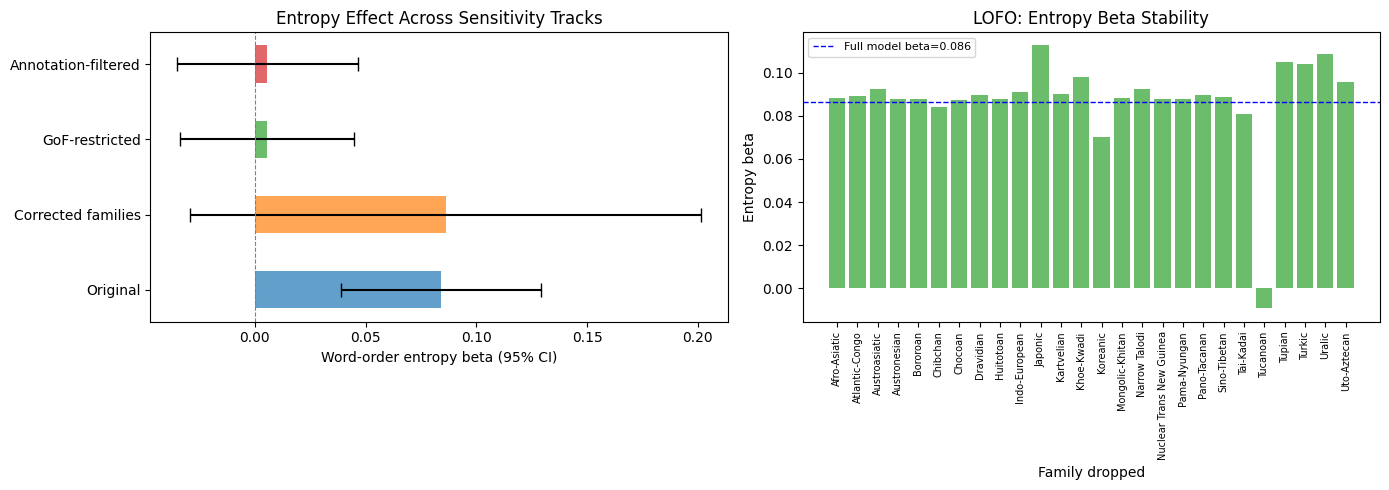

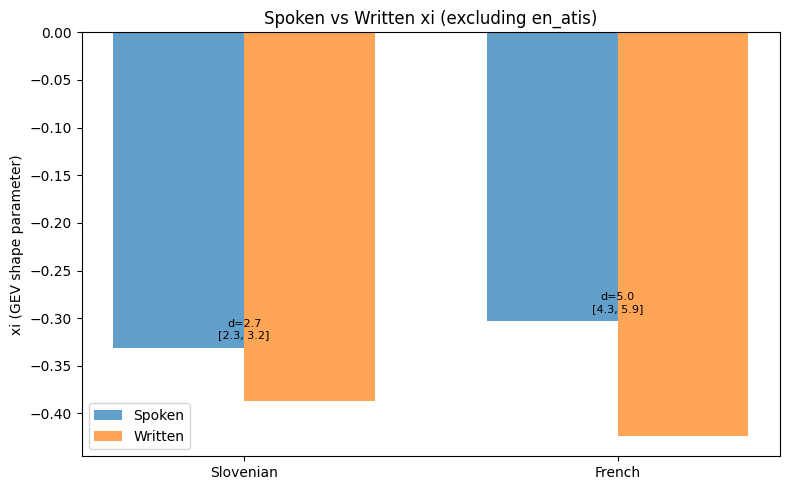

In [15]:
# ============================================================
# Figure 1: Forest plot — entropy beta across sensitivity tracks
# ============================================================
original_entropy_beta = 0.084
original_entropy_se = 0.023

tracks = [("Original", original_entropy_beta, original_entropy_se)]
if c_ent.get("beta") is not None and np.isfinite(c_ent.get("beta", np.nan)):
    tracks.append(("Corrected families", c_ent["beta"], c_ent.get("se", 0)))
if g_ent.get("beta") is not None and np.isfinite(g_ent.get("beta", np.nan)):
    tracks.append(("GoF-restricted", g_ent["beta"], g_ent.get("se", 0)))
if a_ent.get("beta") is not None and np.isfinite(a_ent.get("beta", np.nan)):
    tracks.append(("Annotation-filtered", a_ent["beta"], a_ent.get("se", 0)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Forest plot
ax = axes[0]
labels = [t[0] for t in tracks]
betas = [t[1] for t in tracks]
ci_widths = [1.96 * t[2] for t in tracks]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"][:len(tracks)]
y_pos = range(len(tracks))
ax.barh(list(y_pos), betas, xerr=ci_widths, height=0.5,
        color=colors, alpha=0.7, capsize=5)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels)
ax.axvline(x=0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Word-order entropy beta (95% CI)")
ax.set_title("Entropy Effect Across Sensitivity Tracks")

# Panel 2: LOFO stability
ax2 = axes[1]
family_betas = lofo_results.get("lofo_family_betas", {})
if family_betas:
    fams = sorted(family_betas.keys())
    lofo_betas = [family_betas[f] for f in fams]
    ax2.bar(range(len(fams)), lofo_betas, color="#2ca02c", alpha=0.7)
    ax2.set_xticks(range(len(fams)))
    ax2.set_xticklabels(fams, rotation=90, fontsize=7)
    full_beta = c_ent.get("beta", 0)
    if np.isfinite(full_beta):
        ax2.axhline(y=full_beta, color="blue", linestyle="--",
                    linewidth=1, label=f"Full model beta={full_beta:.3f}")
    ax2.set_xlabel("Family dropped")
    ax2.set_ylabel("Entropy beta")
    ax2.set_title("LOFO: Entropy Beta Stability")
    ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ============================================================
# Figure 2: Spoken vs written paired bar chart
# ============================================================
sw_pairs = sw_results.get("pairs", [])
if sw_pairs:
    fig2, ax3 = plt.subplots(figsize=(8, 5))
    x = np.arange(len(sw_pairs))
    width = 0.35
    spoken_vals = [p["xi_spoken"] for p in sw_pairs]
    written_vals = [p["xi_written"] for p in sw_pairs]
    labels_sw = [p["language"] for p in sw_pairs]
    ax3.bar(x - width/2, spoken_vals, width, label="Spoken", color="#1f77b4", alpha=0.7)
    ax3.bar(x + width/2, written_vals, width, label="Written", color="#ff7f0e", alpha=0.7)
    for i, p in enumerate(sw_pairs):
        d = p["cohens_d"]
        ci = p.get("d_ci", [np.nan, np.nan])
        ax3.annotate(f"d={d:.1f}\n[{ci[0]:.1f}, {ci[1]:.1f}]",
                     xy=(i, max(spoken_vals[i], written_vals[i]) + 0.01),
                     ha="center", fontsize=8)
    ax3.set_xticks(x)
    ax3.set_xticklabels(labels_sw)
    ax3.set_ylabel("xi (GEV shape parameter)")
    ax3.set_title("Spoken vs Written xi (excluding en_atis)")
    ax3.legend()
    plt.tight_layout()
    plt.show()